In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Unique Countries

In [5]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

## Unique customers

In [6]:
df['CustomerID'].nunique()

4372

## InvoiceDate to datetime

In [7]:
# 1. Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## Check For NULL values

In [8]:
print("\nMissing values left in dataset:")
print(df.isnull().sum())


Missing values left in dataset:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
# 2. Drop rows without CustomerID
df = df.dropna(subset=['CustomerID'])

In [10]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df = df.dropna(subset=['Country'])

In [13]:
df.shape

(406829, 8)

## Total Price for Monetary value

In [14]:
# 3. Calculate Total Price for Monetary value
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Calculating RFM Metrics

We need to group the data by CustomerID

For Recency, we'll use a "snapshot date" (the day after the very last purchase in the dataset) to see how many days have passed since each customer's last order.

In [15]:
import datetime as dt
# Set snapshot date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [16]:
# Aggregate data by Customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                   # Frequency
    'TotalPrice': 'sum'                                     # Monetary
})

In [17]:
# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

## Assigning RFM Scores (1 to 5)
We will use quintiles. For Recency, a lower number of days is better, so it gets a higher score. For Frequency and Monetary, higher values get higher scores.

In [18]:
# Create labels for our quintiles
r_labels = range(5, 0, -1) # 5 is best (most recent)
f_labels = range(1, 6)     # 5 is best (most frequent)
m_labels = range(1, 6)     # 5 is best (highest spend)

r_labels = range(5, 0, -1)
Creates labels 5 to 1 for Recency.
Since lower recency (more recent purchase) is better, label 5 = most recent (best).

f_labels = range(1, 6)
Creates labels 1 to 5 for Frequency.
Higher frequency is better, so 5 = most frequent (best).

m_labels = range(1, 6)
Creates labels 1 to 5 for Monetary value.
Higher spending is better, so 5 = highest spenders (best).

In [19]:
# Assign scores
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'], q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

pd.qcut(rfm['Recency'], q=5, labels=r_labels)
Splits Recency into 5 equal-sized groups (quintiles).
Each customer gets a score from 1–5 based on how recent they purchased.

pd.qcut(rfm['Frequency'], q=5, labels=f_labels)
Splits Frequency into 5 equal groups.
Customers who purchase more frequently get higher scores.

pd.qcut(rfm['Monetary'], q=5, labels=m_labels)
Splits Monetary value into 5 equal groups.
Customers who spend more get higher scores.

In [20]:
# Concatenate scores to create an RFM Segment (e.g., "555")
rfm['RFM_Group'] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)

rfm['RFM_Group'] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)
Converts R, F, M scores to strings and concatenates them.
Example:

555 → Best customers (recent, frequent, high spenders)

111 → Lowest-value customers

## Visualizing the Segments

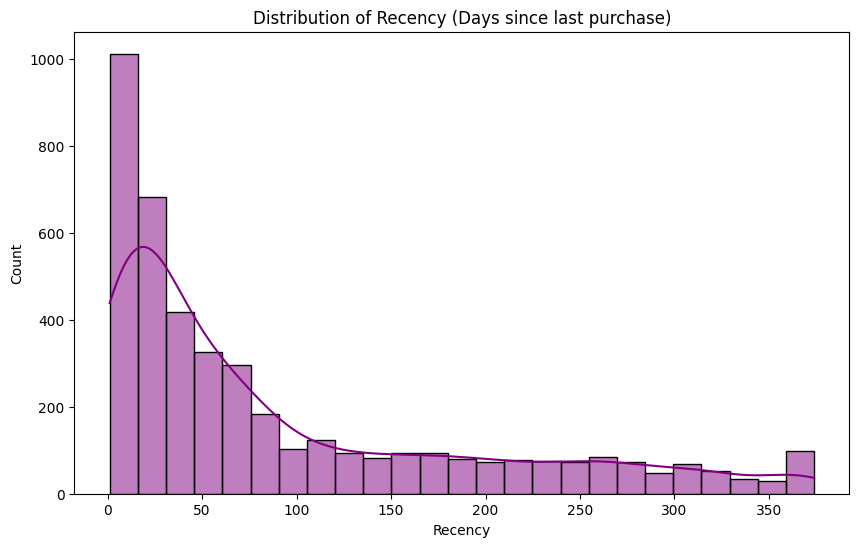

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of Recency
plt.figure(figsize=(10,6))
sns.histplot(rfm['Recency'], kde=True, color='purple')
plt.title('Distribution of Recency (Days since last purchase)')
plt.show()

## Define Segments

In [22]:
# 5. Define Segments
def segment_me(df):
    if df['R'] >= 4 and df['F'] >= 4:
        return 'Champions'
    elif df['R'] >= 3 and df['F'] >= 3:
        return 'Loyal'
    elif df['R'] >= 3:
        return 'Promising/New'
    elif df['R'] <= 2 and df['F'] >= 4:
        return 'At Risk'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

## Segment count plot

/tmp/ipykernel_17/4062690507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', palette='viridis')


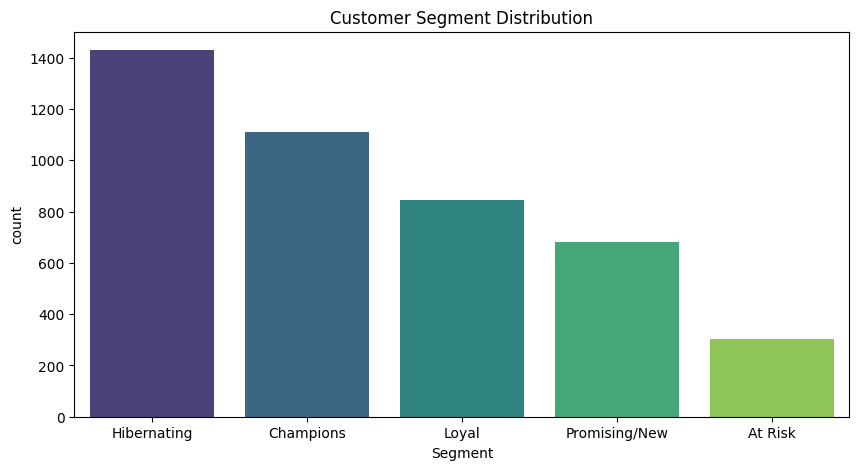

In [23]:
# Quick code for a Segment count plot
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, x='Segment', palette='viridis')
plt.title('Customer Segment Distribution')
plt.show()

## Revenue by Country

In [24]:
# 1. Total Revenue by Country
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

## Customers by Country

In [25]:
# 2. Unique Customers by Country
country_customers = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)

## Visualization

/tmp/ipykernel_17/3010901962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, ax=ax1, palette='magma')
/tmp/ipykernel_17/3010901962.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_customers.values, y=country_customers.index, ax=ax2, palette='viridis')


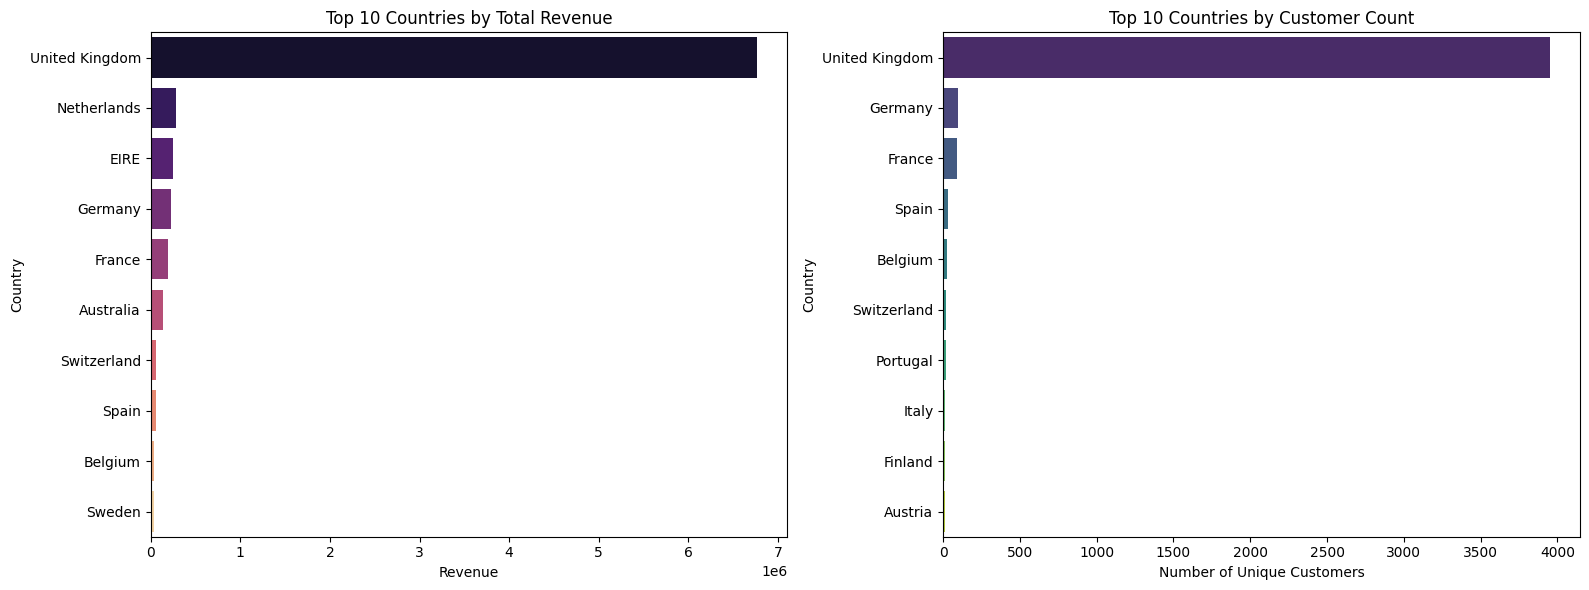

In [26]:

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Revenue
sns.barplot(x=country_revenue.values, y=country_revenue.index, ax=ax1, palette='magma')
ax1.set_title('Top 10 Countries by Total Revenue')
ax1.set_xlabel('Revenue')

# Plot 2: Customer Count
sns.barplot(x=country_customers.values, y=country_customers.index, ax=ax2, palette='viridis')
ax2.set_title('Top 10 Countries by Customer Count')
ax2.set_xlabel('Number of Unique Customers')

plt.tight_layout()
plt.show()